In [1]:
pip install dash

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 6.4 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/8.9 MB 3.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/8.9 MB 2.6 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.9 MB 1.8 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.9 MB 1.8 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.9 MB 1.4 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.9 MB 1.4 MB/s eta 0:00:06
   --------- ------------------------------ 2.1/8.9 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.4/8.9 MB 1.2 MB/s eta 0:00:06
   ----------- ---------------------------- 2.6/8.9 MB 1.2 MB/s eta 0:00:06
   --------------- ------------------------ 3.4/8.9 MB 1.4 MB/s eta 0:00:04
   ---------------- ----------------------- 3.7/8.9 MB 1.4 MB/s eta 0:00:04
   ----------------

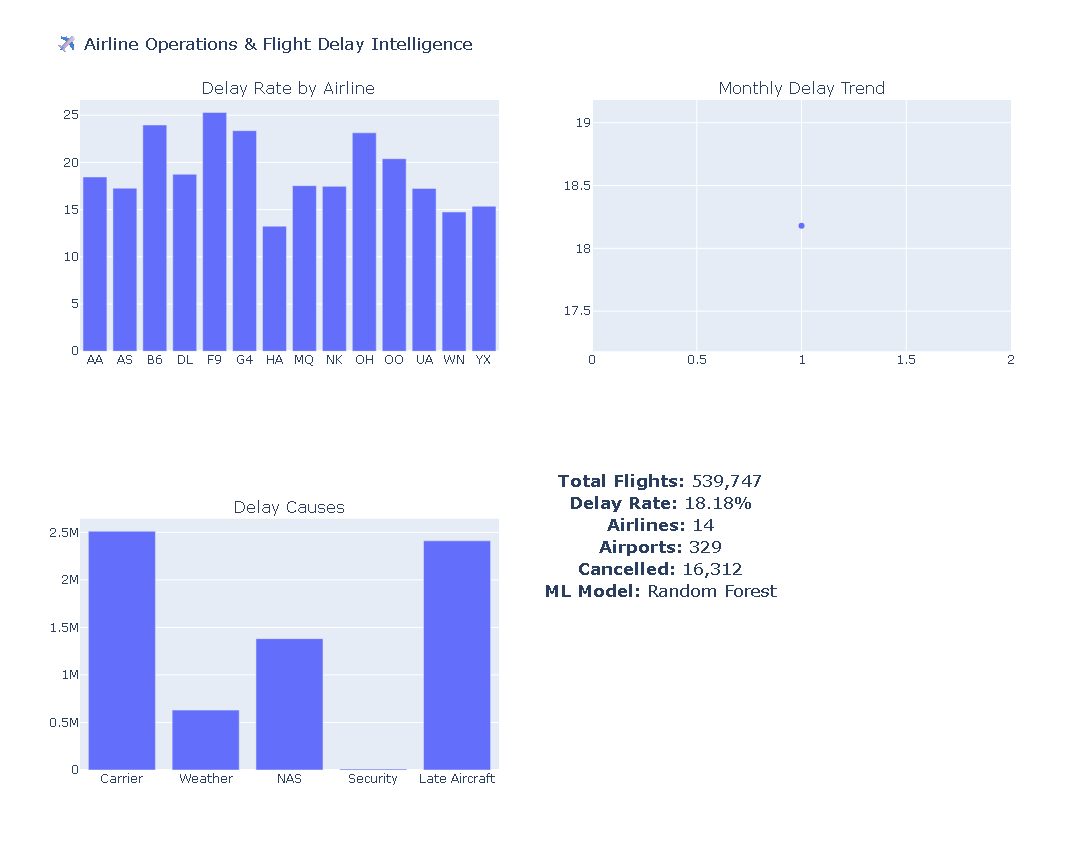

In [9]:
import pandas as pd
import joblib
import plotly.express as px
from plotly.subplots import make_subplots

# Load data and ML model
df = pd.read_csv("airline_cleaned.csv")
model = joblib.load("airline_delay_model.pkl")

# KPIs
total = len(df)
delay = df["ARR_DEL15"].mean() * 100
cancelled = int(df["CANCELLED"].sum())
airlines = df["OP_UNIQUE_CARRIER"].nunique()
airports = len(set(df["ORIGIN"]) | set(df["DEST"]))

# Airline delay
airline_delay = (
    df.groupby("OP_UNIQUE_CARRIER")["ARR_DEL15"]
    .mean().mul(100).reset_index()
)

# Monthly delay
monthly = (
    df.groupby("MONTH")["ARR_DEL15"]
    .mean().mul(100).reset_index()
)

# Delay causes
causes = pd.DataFrame({
    "Cause": ["Carrier", "Weather", "NAS", "Security", "Late Aircraft"],
    "Minutes": [
        df["CARRIER_DELAY"].sum(),
        df["WEATHER_DELAY"].sum(),
        df["NAS_DELAY"].sum(),
        df["SECURITY_DELAY"].sum(),
        df["LATE_AIRCRAFT_DELAY"].sum()
    ]
})

# Charts
fig1 = px.bar(
    airline_delay,
    x="OP_UNIQUE_CARRIER",
    y="ARR_DEL15",
    title="Delay Rate by Airline"
)

fig2 = px.line(
    monthly,
    x="MONTH",
    y="ARR_DEL15",
    markers=True,
    title="Monthly Delay Trend"
)

fig3 = px.bar(
    causes,
    x="Cause",
    y="Minutes",
    title="Delay Causes"
)

# Dashboard
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Delay Rate by Airline",
        "Monthly Delay Trend",
        "Delay Causes"
    ]
)

for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

for trace in fig3.data:
    fig.add_trace(trace, row=2, col=1)

# KPI text
fig.add_annotation(
    text=(
        f"<b>Total Flights:</b> {total:,}<br>"
        f"<b>Delay Rate:</b> {delay:.2f}%<br>"
        f"<b>Airlines:</b> {airlines}<br>"
        f"<b>Airports:</b> {airports}<br>"
        f"<b>Cancelled:</b> {cancelled:,}<br>"
        f"<b>ML Model:</b> Random Forest"
    ),
    x=0.75,
    y=0.25,
    xref="paper",
    yref="paper",
    showarrow=False,
    font=dict(size=17)
)

fig.update_layout(
    title="✈️ Airline Operations & Flight Delay Intelligence",
    height=850,
    showlegend=False
)

fig.write_html("airline_dashboard.html")
fig.show()